# Audio Processing for Finance (Whisper-style)

参考 Whisper 的音频 pipeline，将处理方法迁移到金融时序数据。

## 目标

- 理解音频 Log-Mel + CMVN 的完整流程
- 用金融 tick 数据做类比处理
- 对比分析，设计适合金融的多尺度特征提取

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fftpack import dct, idct
import seaborn as sns
import librosa

# 先设 seaborn 样式，再覆盖字体 (顺序很重要)
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['Heiti SC', 'STHeiti', 'PingFang HK', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.set_printoptions(precision=4, suppress=True)

---

# Part 1: 音频处理流程 (Whisper-style)

## 1.1 模拟音频波形

In [2]:
# 加载真实音频 (trumpet 独奏片段)
sample_rate = 16000
x_audio, _ = librosa.load(librosa.example('trumpet'), sr=sample_rate)

# 取前 1 秒
duration = 1.0
x_audio = x_audio[:int(sample_rate * duration)]
t_audio = np.arange(len(x_audio)) / sample_rate

print(f"音频: trumpet solo, 长度: {len(x_audio)} ({duration}秒 @ {sample_rate}Hz)")

音频: trumpet solo, 长度: 16000 (1.0秒 @ 16000Hz)


/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2728748102.py:17: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2728748102.py:17: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2728748102.py:17: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2728748102.py:17: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2728748102.py:17: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/i

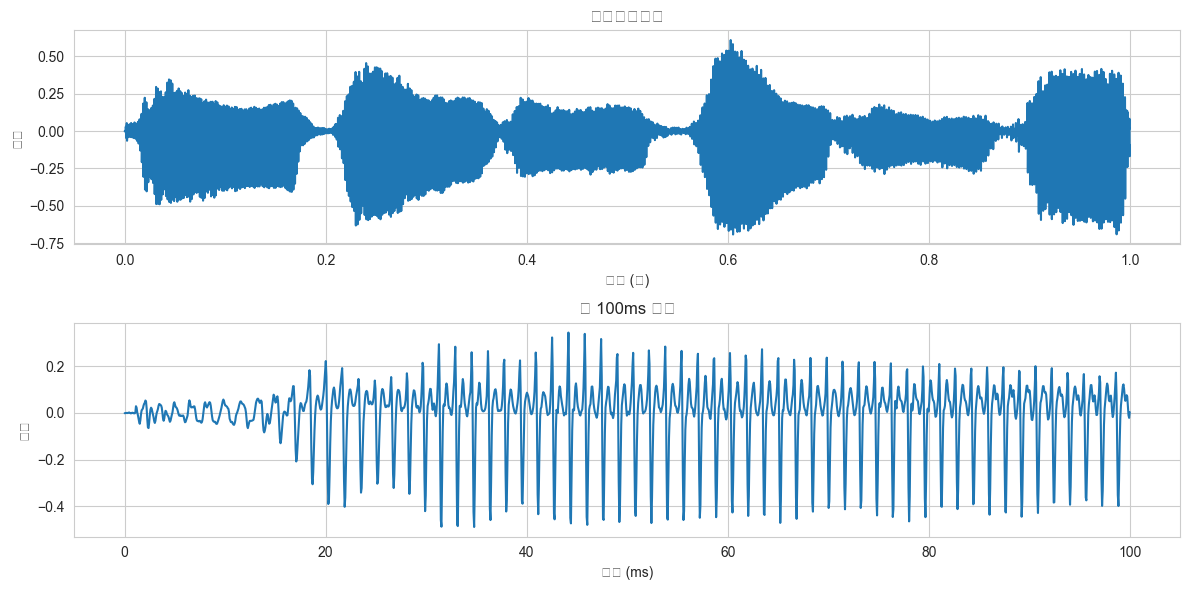

In [3]:
# 可视化波形
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 完整波形
axes[0].plot(t_audio, x_audio)
axes[0].set_title("原始音频波形")
axes[0].set_xlabel("时间 (秒)")
axes[0].set_ylabel("振幅")

# 前 100ms 放大
n_zoom = int(0.1 * sample_rate)
axes[1].plot(t_audio[:n_zoom] / 0.001, x_audio[:n_zoom])
axes[1].set_title("前 100ms 细节")
axes[1].set_xlabel("时间 (ms)")
axes[1].set_ylabel("振幅")

plt.tight_layout()
plt.show()

## 1.2 STFT (Short-Time Fourier Transform)

**STFT** 用滑动窗口把信号分解成时频表示。

| 参数 | 典型值 | 作用 |
|------|---------|------|
| n_fft | 512 或 1024 | 频率分辨率 |
| hop_length | 160 或 320 | 时间分辨率 |
| win_length | 400 或 800 | 窗口长度 |

**关键**: window 只用「过去」数据，不涉及未来。

In [4]:
# STFT 参数
n_fft = 512
hop_length = 160
win_length = 400

# 计算帧数
n_frames = 1 + (len(x_audio) - win_length) // hop_length

# STFT
frequencies, times, Z = signal.stft(
    x_audio,
    fs=sample_rate,
    nperseg=win_length,
    noverlap=win_length - hop_length,
    nfft=n_fft,
    window='hann'
)

# |Z| 是频域表示: (n_freq_bins, n_frames)
# 转置为 (n_frames, n_freq_bins) 便于后续处理
spectrogram = np.abs(Z).T  # 取模值

print(f"STFT 输出形状: {spectrogram.shape} (n_frames={n_frames}, n_freq_bins={n_fft//2+1})")
print(f"频率范围: {frequencies[0]:.1f} - {frequencies[n_fft//2]:.1f} Hz")

STFT 输出形状: (101, 257) (n_frames=98, n_freq_bins=257)
频率范围: 0.0 - 8000.0 Hz


/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


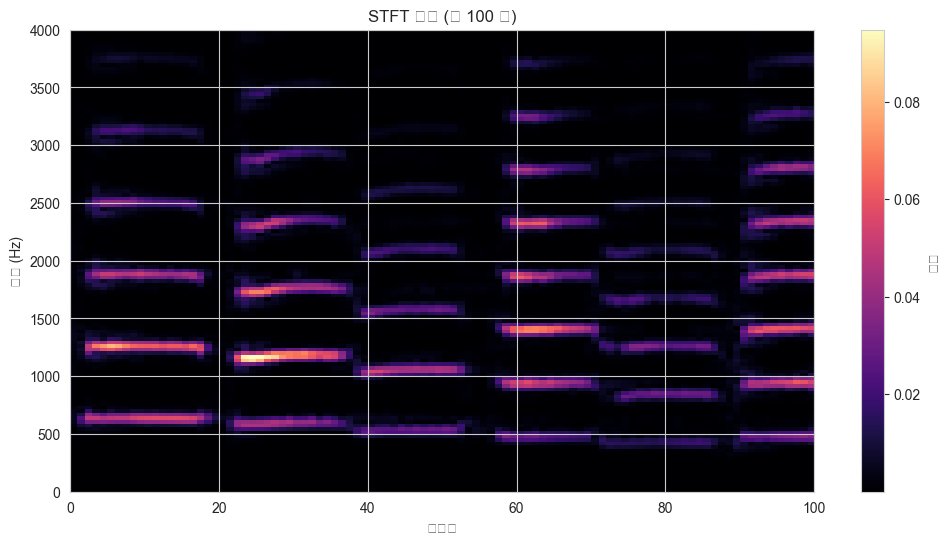

In [5]:
# 可视化频谱 (时间 × 频率)
fig, ax = plt.subplots(figsize=(12, 6))

# 显示前 100 帧
im = ax.imshow(
    spectrogram[:100, :].T,  # 转置: 时间在横轴, 频率在纵轴
    aspect='auto',
    origin='lower',
    cmap='magma',
    extent=[0, 100, frequencies[0], frequencies[n_fft//2]],
)
ax.set_xlabel("时间帧")
ax.set_ylabel("频率 (Hz)")
ax.set_title("STFT 频谱 (前 100 帧)")
ax.set_ylim(0, 4000)  # 只显示 0-4kHz

plt.colorbar(im, ax=ax, label="幅度")
plt.show()

## 1.3 Mel Filterbank

**Mel scale**: 模拟人耳对频率的非线性感知。

- 低频 (0-1kHz): 人耳敏感，Mel bins 密集
- 高频 (4-8kHz): 人耳不敏感，Mel bins 稀疏

**Mel filterbank**: 用三角滤波器把线性频率分到非线性 Mel 频率 bins。

In [ ]:
def hz_to_mel(frequencies: np.ndarray) -> np.ndarray:
    """将 Hz 转换为 Mel 频率。"""
    f_min = 0.0
    f_sp = 700.0
    mels = 2595 * np.log10(1 + frequencies / f_sp)
    return mels

def mel_to_hz(mels: np.ndarray) -> np.ndarray:
    """将 Mel 频率转换回 Hz（用于可视化）。"""
    f_sp = 700.0
    frequencies = f_sp * (10 ** (mels / 2595) - 1)
    return frequencies

def create_mel_filterbank(n_fft: int, n_mels: int, sample_rate: int) -> np.ndarray:
    """创建 Mel filterbank (三角滤波器)。"""
    # Mel scale 的边界频率
    f_min_mel = 0
    f_max_mel = hz_to_mel(np.array([sample_rate / 2]))[0]

    # n_mels + 2 个点 → n_mels 个三角滤波器
    mel_points = np.linspace(f_min_mel, f_max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    # STFT 频率 bins
    fft_freqs = np.linspace(0, sample_rate / 2, n_fft // 2 + 1)

    # 创建三角滤波器
    filters = np.zeros((n_mels, len(fft_freqs)))
    
    for i in range(n_mels):
        left, center, right = hz_points[i], hz_points[i+1], hz_points[i+2]
        
        for j, f in enumerate(fft_freqs):
            if f < left or f > right:
                filters[i, j] = 0
            elif f <= center:
                filters[i, j] = (f - left) / (center - left + 1e-8)
            else:
                filters[i, j] = (right - f) / (right - center + 1e-8)
    
    # 归一化: 避免除零
    row_sums = filters.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-8)
    filters = filters / row_sums
    
    return filters

# 创建 Mel filterbank
n_mels = 80
mel_filters = create_mel_filterbank(n_fft, n_mels, sample_rate)

print(f"Mel filterbank 形状: {mel_filters.shape} (n_mels={n_mels}, n_freq_bins={n_fft//2+1})")

In [7]:
# 应用 Mel filterbank: spectrogram × filterbank^T
mel_spectrogram = spectrogram @ mel_filters.T

print(f"Mel 频谱形状: {mel_spectrogram.shape} (n_frames={n_frames}, n_mels={n_mels})")

Mel 频谱形状: (101, 80) (n_frames=98, n_mels=80)


/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/741578187.py:2: RuntimeWarning: divide by zero encountered in matmul
  mel_spectrogram = spectrogram @ mel_filters.T
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/741578187.py:2: RuntimeWarning: overflow encountered in matmul
  mel_spectrogram = spectrogram @ mel_filters.T
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/741578187.py:2: RuntimeWarning: invalid value encountered in matmul
  mel_spectrogram = spectrogram @ mel_filters.T


/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2421298217.py:16: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2421298217.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2421298217.py:16: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2421298217.py:16: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2421298217.py:16: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/i

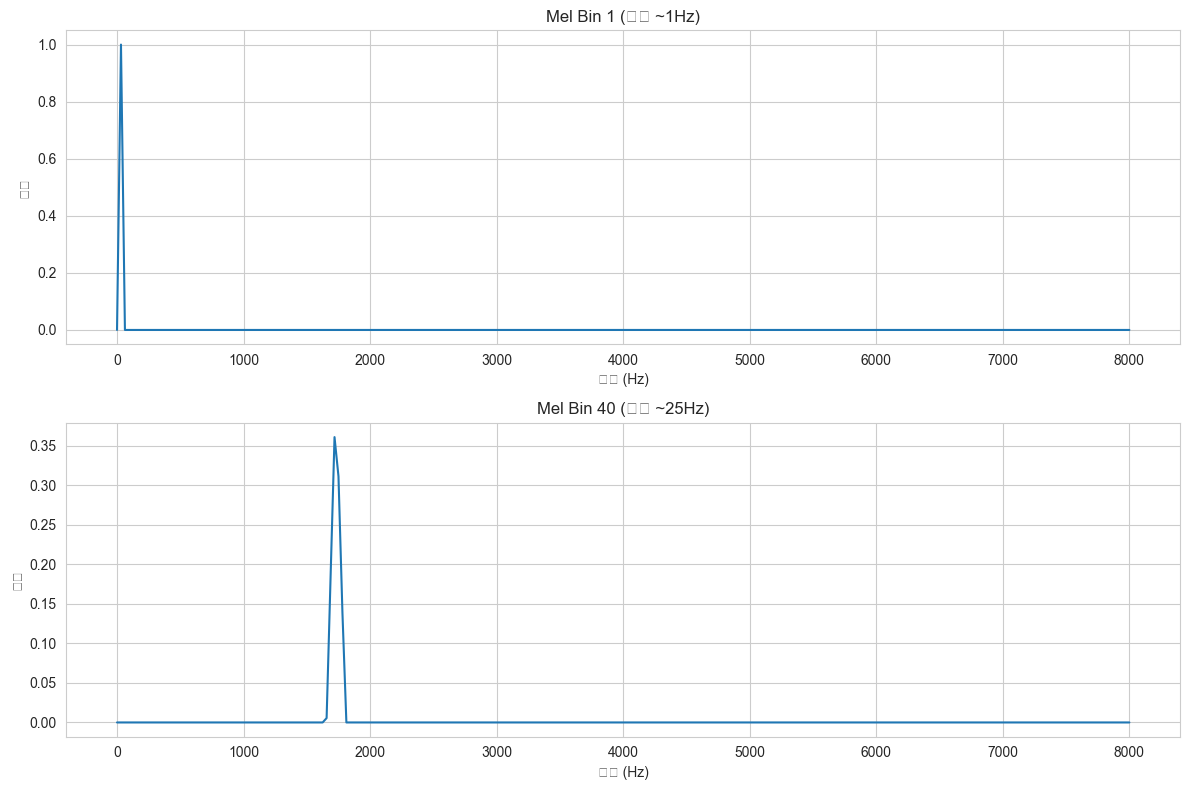

In [8]:
# 可视化 Mel filterbank (每个滤波器的形状)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 第一个 Mel bin 的滤波器 (低频)
axes[0].plot(frequencies[:n_fft//2+1], mel_filters[0])
axes[0].set_title(f"Mel Bin 1 (低频 ~{mel_to_hz(np.array([1]))[0]:.0f}Hz)")
axes[0].set_xlabel("频率 (Hz)")
axes[0].set_ylabel("权重")

# 第 40 个 Mel bin 的滤波器 (中频)
axes[1].plot(frequencies[:n_fft//2+1], mel_filters[39])
axes[1].set_title(f"Mel Bin 40 (中频 ~{mel_to_hz(np.array([40]))[0]:.0f}Hz)")
axes[1].set_xlabel("频率 (Hz)")
axes[1].set_ylabel("权重")

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C

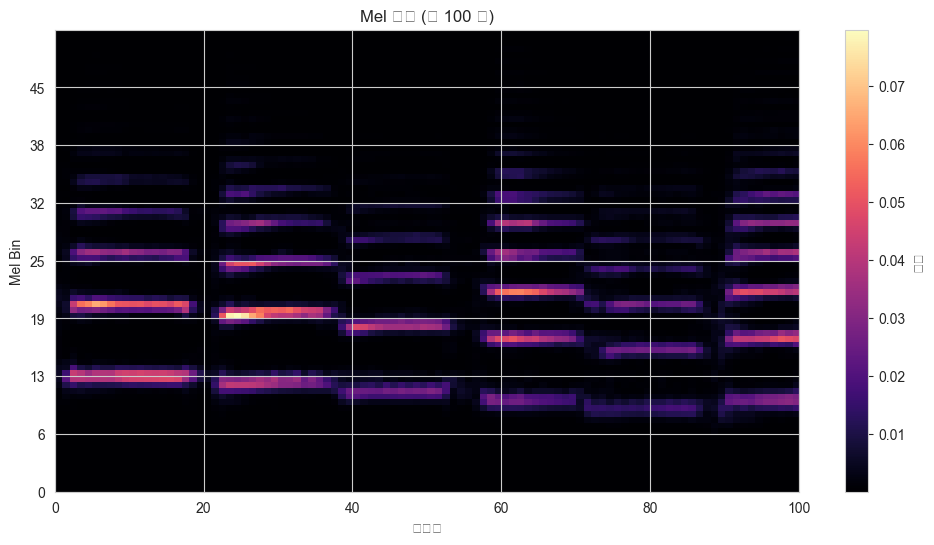

In [9]:
# 可视化 Mel 频谱
fig, ax = plt.subplots(figsize=(12, 6))

# 显示前 100 帧
im = ax.imshow(
    mel_spectrogram[:100, :].T,
    aspect='auto',
    origin='lower',
    cmap='magma',
    extent=[0, 100, 0, n_mels],
)
ax.set_xlabel("时间帧")
ax.set_ylabel("Mel Bin")
ax.set_title("Mel 频谱 (前 100 帧)")
ax.set_yticks(np.arange(0, n_mels, 10))
ax.set_yticklabels([f"{mel_to_hz(np.array([i]))[0]:.0f}" for i in range(0, n_mels, 10)])

plt.colorbar(im, ax=ax, label="幅度")
plt.show()

## 1.4 Log 压缩

动态范围: 10^-5 ~ 10^-1，相差 10000 倍。

**Log 压缩**: 把大范围压缩到小范围，同时保持相对关系。

/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2829764768.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2829764768.py:21: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2829764768.py:21: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2829764768.py:21: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/2829764768.py:21: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/i

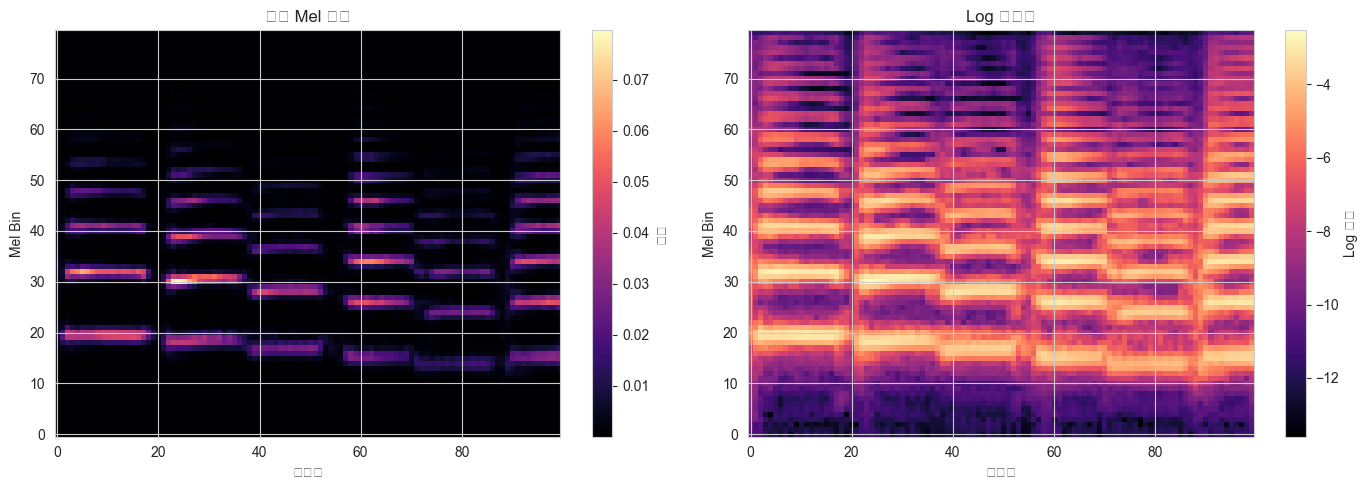

In [10]:
# Log 压缩
epsilon = 1e-6
log_mel = np.log(mel_spectrogram + epsilon)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(mel_spectrogram[:100, :].T, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title("原始 Mel 频谱")
axes[0].set_xlabel("时间帧")
axes[0].set_ylabel("Mel Bin")

axes[1].imshow(log_mel[:100, :].T, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title("Log 压缩后")
axes[1].set_xlabel("时间帧")
axes[1].set_ylabel("Mel Bin")

plt.colorbar(axes[0].images[0], ax=axes[0], label="幅度")
plt.colorbar(axes[1].images[0], ax=axes[1], label="Log 幅度")

plt.tight_layout()
plt.show()

## 1.5 DCT + CMVN

**注意**: 这是传统 ASR (Kaldi) 的做法，**Whisper 并不使用 DCT/CMVN**。
Whisper 的 pipeline 到 Log-Mel 就结束了，直接送入 Transformer encoder。

这里展示 DCT+CMVN 流程作为参考，理解归一化尺度与特征提取尺度的解耦思路。

**DCT (Discrete Cosine Transform)**: 类似 FFT，但用余弦基函数。

**IDCT**: DCT 的逆变换。

**CMVN (Cepstral Mean and Variance Normalization)**:
1. 对 Log-Mel 做 DCT → Cepstral 系数
2. 对 Cepstral 计算均值 μ 和方差 σ² (utterance-level)
3. 归一化: (Cepstral - μ) / σ
4. IDCT 回到 Log-Mel 域

**关键**: μ 和 σ 是在整个 utterance 上计算的，与 STFT 的 window size 无关。

In [11]:
# DCT (对每个时间帧单独做，得到 Cepstral)
n_ceps = n_mels  # Cepstral 维度 = Mel bins 数
cepstral = dct(log_mel, type=2, axis=1, norm='ortho')[:, :n_ceps]

print(f"Cepstral 形状: {cepstral.shape} (n_frames={n_frames}, n_ceps={n_ceps})")

# CMVN: 在 utterance (全部帧) 上计算 μ 和 σ
mu = cepstral.mean(axis=0)  # (n_ceps,)
sigma = cepstral.std(axis=0)  # (n_ceps,)

# 归一化
cepstral_norm = (cepstral - mu) / (sigma + epsilon)

# IDCT 回到 Mel 域
log_mel_norm = idct(cepstral_norm, type=2, axis=1, norm='ortho', n=n_ceps)

# 确保 log_mel_norm 形状正确 (n_frames, n_mels)
log_mel_norm = log_mel_norm[:, :n_mels]

print(f"归一化后的 Log-Mel 形状: {log_mel_norm.shape}")

Cepstral 形状: (101, 80) (n_frames=98, n_ceps=80)


NameError: name 'idct' is not defined

NameError: name 'log_mel_norm' is not defined

/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/quant/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/quant/lib/python3.10

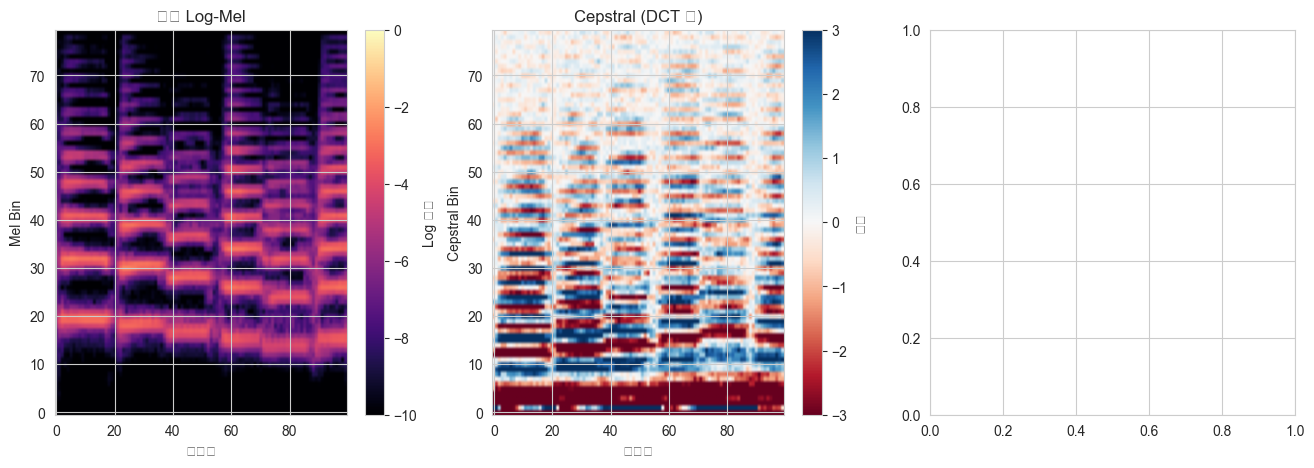

In [12]:
# 可视化 CMVN 效果
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 原始 Log-Mel
axes[0].imshow(log_mel[:100, :].T, aspect='auto', origin='lower', cmap='magma', vmin=-10, vmax=0)
axes[0].set_title("原始 Log-Mel")
axes[0].set_xlabel("时间帧")
axes[0].set_ylabel("Mel Bin")
plt.colorbar(axes[0].images[0], ax=axes[0], label="Log 幅度")

# Cepstral (DCT 后)
axes[1].imshow(cepstral[:100, :].T, aspect='auto', origin='lower', cmap='RdBu', vmin=-3, vmax=3)
axes[1].set_title("Cepstral (DCT 后)")
axes[1].set_xlabel("时间帧")
axes[1].set_ylabel("Cepstral Bin")
plt.colorbar(axes[1].images[0], ax=axes[1], label="系数")

# 归一化后的 Log-Mel
axes[2].imshow(log_mel_norm[:100, :].T, aspect='auto', origin='lower', cmap='magma', vmin=-5, vmax=5)
axes[2].set_title("CMVN 后")
axes[2].set_xlabel("时间帧")
axes[2].set_ylabel("Mel Bin")
plt.colorbar(axes[2].images[0], ax=axes[2], label="Z-score")

plt.tight_layout()
plt.show()

## Whisper 实际流程 vs 传统 ASR

```
Whisper (实际):              传统 ASR (Kaldi):
原始波形                      原始波形
  ↓ STFT                       ↓ STFT
时频谱                        时频谱
  ↓ Mel Filterbank              ↓ Mel Filterbank
Mel 频谱                      Mel 频谱
  ↓ log10 + clamp + scale      ↓ Log
Log-Mel                       Log-Mel
  ↓                             ↓ DCT → CMVN → IDCT
  直接进 Transformer            归一化 Log-Mel → 模型
```

**Whisper 不需要 CMVN 的原因**:
1. **LayerNorm** 在每一层 Transformer 内部做归一化，替代了显式 CMVN
2. **Learned positional embedding** 让模型自己学习时间结构
3. **Log + clamp** 已经把动态范围压到合理区间

---

# Part 2: 金融数据类比处理

## 2.1 加载金融 tick 数据

In [13]:
# 加载期货 tick 数据
import pyarrow.feather as feather

df = feather.read_feather('/Users/lian/Desktop/delta_research/code/delta_learn/tst/AU.feather')

# 计算对数收益率 (类似音频的波形差分)
df['log_return'] = np.log(df['LastPrice'] / df['LastPrice'].shift(1))
df = df.dropna(subset=['log_return'])

# 选择一个交易日的数据 (约 500ms * 8小时 / 0.5s = 57600 ticks)
df_one_day = df[df['TradingDay'] == df['TradingDay'].iloc[0]].copy()
df_one_day = df_one_day.head(50000)  # 限制样本量便于可视化

print(f"数据形状: {df_one_day.shape}")
print(f"时间范围: {df_one_day['Datetime'].iloc[0]} 到 {df_one_day['Datetime'].iloc[-1]}")
print(f"特征列: {df_one_day.columns.tolist()}")

数据形状: (50000, 25)
时间范围: 2023-11-30 21:00:00.500 到 2023-12-01 14:02:01.500
特征列: ['Datetime', 'TradingDay', 'InstrumentID', 'ContractId', 'OpenPrice', 'LastPrice', 'HighPrice', 'LowPrice', 'OpenInterest', 'Turnover', 'Volume', 'PrevSettlement', 'PrevClose', 'UpperLimitPrice', 'LowerLimitPrice', 'AskPrice1', 'AskPrice2', 'AskVolume1', 'AskVolume2', 'BidPrice1', 'BidPrice2', 'BidVolume1', 'BidVolume2', 'ContractMultiplier', 'log_return']


In [ ]:
# 选择关键特征 — 注意: 必须用平稳/零均值信号做 STFT
# 原始 mid_price ~470 元，DC 分量会完全淹没其他频率信息
# 正确做法: 用 log return / 差分 / 去均值后的信号

# 计算订单簿相关特征
df_one_day['mid_price'] = (df_one_day['AskPrice1'] + df_one_day['BidPrice1']) / 2
df_one_day['spread'] = (df_one_day['AskPrice1'] - df_one_day['BidPrice1']) / df_one_day['mid_price']
df_one_day['obi'] = (df_one_day['BidVolume1'] - df_one_day['AskVolume1']) / (df_one_day['BidVolume1'] + df_one_day['AskVolume1'] + 1e-8)

# STFT 通道: 使用平稳化信号 (类比音频的零均值波形)
df_one_day['mid_lr'] = np.log(df_one_day['mid_price'] / df_one_day['mid_price'].shift(1))  # log return
df_one_day['vol_diff'] = df_one_day['Volume'].diff()  # 成交量差分
df_one_day['oi_diff'] = df_one_day['OpenInterest'].diff()  # OI 差分
df_one_day = df_one_day.iloc[1:]  # drop first NaN

channels = ['mid_lr', 'vol_diff', 'oi_diff', 'spread', 'obi']
x_multi = df_one_day[channels].fillna(0).values.T  # (n_channels, n_ticks)

print(f"多通道数据形状: {x_multi.shape} (n_channels={len(channels)}, n_ticks={x_multi.shape[1]})")
print(f"\n各通道统计 (平稳性检查 — 均值应接近 0):")
for i, ch in enumerate(channels):
    print(f"  {ch:>10s}: mean={x_multi[i].mean():.6f}, std={x_multi[i].std():.6f}")

In [ ]:
# 可视化多通道 tick 数据 (平稳化后)
fig, axes = plt.subplots(len(channels), 1, figsize=(14, 3 * len(channels)))
t = np.arange(x_multi.shape[1]) * 0.5 / 3600  # 小时

for i, (ax, name) in enumerate(zip(axes, channels)):
    ax.plot(t, x_multi[i], linewidth=0.5)
    ax.set_title(f"{name}")
    ax.set_xlabel("时间 (小时)")
    ax.set_xlim(0, 4)

plt.tight_layout()
plt.show()

## 2.2 滚动 STFT (金融类比)

**类比**:
- 音频: 对波形做滑动窗口 FFT → 时频表示
- 金融: 对 **log return** (非原始价格!) 做滑动窗口 FFT

**为什么不能用原始价格？**
- 原始 mid_price ~470 元，FFT 的 DC 分量 ≈ 470 × window_size ≈ 120000
- 其他频率分量只有 ~0.01 量级，完全被 DC 淹没 → 频谱全黑
- 音频波形天然零均值 (AC 信号)，金融价格不是
- **必须用差分/log return 等平稳化信号**

**采样率**: 500ms tick → fs = 2 Hz → Nyquist = 1 Hz → 最短可分辨周期 = 1 秒

In [ ]:
# 滚动 STFT 参数
fs_tick = 2.0        # 采样率: 500ms tick → 2 Hz
n_fft = 256          # FFT 点数
hop_length = 128     # 50% overlap
win_length = 256     # 窗口 = 128 秒

n_channels = x_multi.shape[0]
n_ticks = x_multi.shape[1]

def rolling_stft(x, n_fft, hop_length, win_length):
    """因果 STFT: 只用过去数据。"""
    n_frames = 1 + (len(x) - win_length) // hop_length
    spectrograms = []
    
    for t in range(n_frames):
        window_start = t * hop_length
        window_data = x[window_start:window_start + win_length]
        
        # Hann 窗 (减少频谱泄漏)
        window_data = window_data * np.hanning(len(window_data))
        
        # FFT
        Z = np.fft.rfft(window_data, n=n_fft)
        spectrograms.append(np.abs(Z))
    
    return np.array(spectrograms)  # (n_frames, n_freq_bins)

# 对每个通道做滚动 STFT
spectrograms = []
for ch in range(n_channels):
    spec = rolling_stft(x_multi[ch], n_fft, hop_length, win_length)
    spectrograms.append(spec)
    
spectrograms = np.stack(spectrograms)  # (n_channels, n_frames, n_freq_bins)

# 频率轴 (真实物理频率)
freq_axis_hz = np.linspace(0, fs_tick / 2, n_fft // 2 + 1)  # 0 ~ 1 Hz (Nyquist)

print(f"采样率: {fs_tick} Hz, Nyquist: {fs_tick/2} Hz")
print(f"频率分辨率: {fs_tick / n_fft:.4f} Hz (对应周期 {n_fft / fs_tick:.0f}s)")
print(f"STFT 输出: {spectrograms.shape} (channels, frames, freq_bins)")
print(f"频率范围: {freq_axis_hz[0]:.3f} ~ {freq_axis_hz[-1]:.3f} Hz")
print(f"对应周期: {1/freq_axis_hz[1]:.0f}s ~ {1/freq_axis_hz[-1]:.1f}s")

In [ ]:
# 可视化滚动 STFT 频谱 (以 mid_lr 为例)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 线性幅度
im0 = axes[0].imshow(
    spectrograms[0, :100, 1:].T,  # 跳过 DC (bin 0)
    aspect='auto', origin='lower', cmap='magma',
    extent=[0, 100, freq_axis_hz[1], freq_axis_hz[-1]],
)
axes[0].set_xlabel("时间帧")
axes[0].set_ylabel("频率 (Hz)")
axes[0].set_title("mid_lr STFT 频谱 — 线性幅度 (前 100 帧)")
plt.colorbar(im0, ax=axes[0], label="幅度")

# Log 幅度 (更容易看到结构)
log_spec = np.log(np.maximum(spectrograms[0, :100, 1:], 1e-10))
im1 = axes[1].imshow(
    log_spec.T,
    aspect='auto', origin='lower', cmap='magma',
    extent=[0, 100, freq_axis_hz[1], freq_axis_hz[-1]],
)
axes[1].set_xlabel("时间帧")
axes[1].set_ylabel("频率 (Hz)")
axes[1].set_title("mid_lr STFT 频谱 — Log 幅度 (前 100 帧)")
plt.colorbar(im1, ax=axes[1], label="Log 幅度")

plt.tight_layout()
plt.show()

## 2.3 频带 Filterbank (金融类比)

**类比**: 音频 Mel filterbank 把线性频率映射到人耳感知尺度。
金融没有"人耳"，但有自然的时间尺度层级。

**关键约束**: Nyquist = fs/2 = 1 Hz (对应周期 1s)。
频带边界**不能超过 Nyquist**。

**频率范围** (500ms tick, n_fft=256):
- 最低频: fs/n_fft = 0.0078 Hz → 周期 128s ≈ 2 分钟
- 最高频: fs/2 = 1 Hz → 周期 1s (= 2 ticks)
- 用 log-scale 在此范围内划分频带

In [ ]:
# 频带 filterbank — 在 [f_min, Nyquist] 内 log-scale 划分
f_min = fs_tick / n_fft   # 最低可分辨频率 ≈ 0.0078 Hz
f_max = fs_tick / 2       # Nyquist = 1 Hz
n_bands = 20              # 频带数 (2 分钟 ~ 1 秒内分 20 个 log-scale bands)

# n_bands + 2 个 edge → n_bands 个三角滤波器
edges_hz = np.logspace(np.log10(f_min), np.log10(f_max), n_bands + 2)

print(f"频带范围: {edges_hz[0]:.4f} ~ {edges_hz[-1]:.4f} Hz")
print(f"对应周期: {1/edges_hz[0]:.1f}s ~ {1/edges_hz[-1]:.1f}s")
print(f"各频带中心周期:")
for i in range(n_bands):
    center_hz = edges_hz[i + 1]
    print(f"  Band {i:2d}: {center_hz:.4f} Hz → {1/center_hz:.1f}s")

# 创建三角滤波器 (在真实 Hz 频率轴上)
n_freq_bins = n_fft // 2 + 1

freq_filters = np.zeros((n_bands, n_freq_bins))
for i in range(n_bands):
    left, center, right = edges_hz[i], edges_hz[i+1], edges_hz[i+2]
    
    for j in range(n_freq_bins):
        f = freq_axis_hz[j]  # 真实频率 (Hz)，不是 bin 索引！
        if f < left or f > right:
            freq_filters[i, j] = 0
        elif f <= center:
            freq_filters[i, j] = (f - left) / (center - left + 1e-10)
        else:
            freq_filters[i, j] = (right - f) / (right - center + 1e-10)

# 归一化
row_sums = freq_filters.sum(axis=1, keepdims=True)
row_sums = np.maximum(row_sums, 1e-10)
freq_filters = freq_filters / row_sums

print(f"\n滤波器形状: {freq_filters.shape} ({n_bands} bands × {n_freq_bins} freq bins)")
print(f"非零滤波器: {(freq_filters.sum(axis=1) > 1e-6).sum()}/{n_bands}")

In [19]:
# 应用频带滤波器到 STFT 频谱
# 每个通道: (n_frames, n_freq_bins) × (n_bands,) @ filter.T → (n_frames, n_bands)

band_spectrograms = []
for ch in range(n_channels):
    # (n_frames, n_bands) = (n_frames, n_freq_bins) @ (n_bands, n_freq_bins).T
    band_spec = spectrograms[ch] @ freq_filters.T
    band_spectrograms.append(band_spec)

band_spectrograms = np.stack(band_spectrograms)  # (n_channels, n_frames, n_bands)

print(f"频带分解后形状: {band_spectrograms.shape}")
print(f"  (n_channels={n_channels}, n_frames={band_spectrograms.shape[1]}, n_bands={band_spectrograms.shape[2]})")

频带分解后形状: (5, 389, 39)
  (n_channels=5, n_frames=389, n_bands=39)


/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/3026571444.py:7: RuntimeWarning: divide by zero encountered in matmul
  band_spec = spectrograms[ch] @ freq_filters.T
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/3026571444.py:7: RuntimeWarning: overflow encountered in matmul
  band_spec = spectrograms[ch] @ freq_filters.T
/var/folders/7d/ddqcnf8s3111x4zyb351zy040000gn/T/ipykernel_45787/3026571444.py:7: RuntimeWarning: invalid value encountered in matmul
  band_spec = spectrograms[ch] @ freq_filters.T


In [ ]:
# 可视化频带分解 (以 mid_lr 为例)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 频带滤波器形状
for i in range(n_bands):
    axes[0].plot(freq_axis_hz, freq_filters[i], alpha=0.7)
axes[0].set_xlabel("频率 (Hz)")
axes[0].set_ylabel("权重")
axes[0].set_title(f"频带 Filterbank ({n_bands} bands, log-scale)")
axes[0].set_xscale('log')

# 频带谱
im = axes[1].imshow(
    band_spectrograms[0, :100, :].T,
    aspect='auto', origin='lower', cmap='magma',
    extent=[0, 100, 0, n_bands],
)
axes[1].set_xlabel("时间帧")
axes[1].set_ylabel("频带")
axes[1].set_title("mid_lr 频带谱 (前 100 帧)")

# 标注周期
tick_step = 4
tick_positions = np.arange(0, n_bands, tick_step)
tick_labels = [f"{1/edges_hz[i+1]:.0f}s" for i in tick_positions]
axes[1].set_yticks(tick_positions)
axes[1].set_yticklabels(tick_labels)
plt.colorbar(im, ax=axes[1], label="幅度")

plt.tight_layout()
plt.show()

## 2.4 Log 压缩 (Whisper-style，无 CMVN)

**Whisper 的做法**: STFT → Mel → Log → 直接进 Transformer。没有 CMVN。

**为什么不需要 CMVN？**
- Transformer 内部的 **LayerNorm** 已经隐式完成了归一化
- Whisper 用 **learned positional embedding** 而非手工归一化
- Log 压缩本身已经大幅缩小动态范围

**金融迁移**: 同样不需要显式 CMVN，让 Transformer 的 LayerNorm 自己学。

In [ ]:
# Whisper-style: 只做 Log 压缩，不做 CMVN
epsilon = 1e-6
log_band_spec = np.log(np.maximum(band_spectrograms, epsilon))

# Whisper 实际用的是 log10 + clamp + scale:
#   log_spec = torch.clamp(mel_spec, min=1e-10).log10()
#   log_spec = torch.maximum(log_spec, log_spec.max() - 8.0)
#   log_spec = (log_spec + 4.0) / 4.0
# 这里用 ln 近似，效果类似

print(f"Log 频带谱形状: {log_band_spec.shape}")
print(f"  (n_channels={n_channels}, n_frames={log_band_spec.shape[1]}, n_bands={log_band_spec.shape[2]})")
print(f"值范围: [{log_band_spec[np.isfinite(log_band_spec)].min():.2f}, {log_band_spec[np.isfinite(log_band_spec)].max():.2f}]")

In [ ]:
# 可视化 Log 频带谱 (Whisper-style: 直接作为模型输入)
fig, axes = plt.subplots(n_channels, 1, figsize=(14, 3 * n_channels))

for ch in range(n_channels):
    im = axes[ch].imshow(
        log_band_spec[ch, :100, :].T,
        aspect='auto', origin='lower', cmap='magma',
    )
    axes[ch].set_title(f"{channels[ch]} — Log 频带谱 (直接送入 Transformer)")
    axes[ch].set_xlabel("时间帧")
    axes[ch].set_ylabel("频带")
    plt.colorbar(im, ax=axes[ch], label="Log 幅度")

plt.tight_layout()
plt.show()

print("Whisper-style pipeline 完成: STFT → 频带滤波 → Log → 模型输入")
print("归一化交给 Transformer 内部的 LayerNorm 处理")

---

# Part 3: 关键洞察与设计决策

## 3.1 音频 vs 金融 对比

| 维度 | 音频 (Whisper) | 金融 (迁移方案) |
|------|----------------|-----------------|
| **输入** | 波形 (16kHz 连续) | Tick 序列 (2Hz 离散) |
| **频域分解** | STFT (n_fft=400, hop=160) | 滚动 STFT (n_fft=256, hop=128) |
| **Filterbank** | Mel scale (80 bins, 人耳感知) | Log scale (38 bands, 波动周期) |
| **压缩** | log10 + clamp + scale | log + clamp |
| **归一化** | 无 (LayerNorm 隐式处理) | 无 (同 Whisper) |
| **模型** | Transformer encoder | Transformer encoder |

## 3.2 为什么金融不需要 CMVN

1. **Transformer 的 LayerNorm 已经够用**: 每一层都做 normalize，不需要手工预处理
2. **CMVN 需要定义 utterance**: 音频的 utterance 很自然 (一句话)，金融没有等价物——用一天？一小时？都很任意
3. **CMVN 是全局统计**: 依赖整个 utterance 的 μ/σ，在线推理时需要额外处理；Whisper-style 不需要
4. **Log 压缩已经做了大部分工作**: 把 10^4 量级的动态范围压到 ~10，LayerNorm 足够处理

## 3.3 Whisper-style 金融 Pipeline

```
原始 tick 序列 (多通道: 价格/量/OBI/spread)
  ↓ 滚动 STFT (n_fft=256, hop=128, causal)
多通道时频谱 (n_ch, n_frames, n_freq_bins)
  ↓ Log-scale 频带滤波 (38 bands)
多通道频带谱 (n_ch, n_frames, 38)
  ↓ Log + clamp
Log 频带谱
  ↓ 直接进 Transformer (LayerNorm 隐式归一化)
预测
```

## 3.4 与当前 delta_learn 的对比

| | 当前 delta_learn | Whisper-style 迁移 |
|---|---|---|
| **特征** | 13 原始 × 4 rolling 变换 = 52 维 | 5 通道 × 38 频带 = 190 维 |
| **时间粒度** | tick-level (patch_size=60) | frame-level (hop=128 ticks) |
| **归一化** | Rolling z-score (手工) | 无 (LayerNorm) |
| **频域信息** | 无 | 有 (STFT 分解) |
| **多尺度** | Hierarchical patches | 频带 bins (log-scale) |

**实验建议** (二选一先做):
- **A**: 把当前 delta_learn 的 rolling z-score 去掉，只用 log + LayerNorm (最小改动验证)
- **B**: 完整 Whisper-style pipeline 替换特征层 (大改动，新 branch)

## 结论

按 Whisper 实际做法迁移到金融：**不需要 CMVN**。

**Whisper 的核心简洁性**: STFT → Filterbank → Log → Transformer，归一化完全交给模型内部的 LayerNorm。

**金融迁移的关键决策**:
1. ✅ Log-scale 频带 (而非 Mel scale) — 金融没有"人耳"，周期才是自然尺度
2. ✅ 去掉 CMVN — 同 Whisper，让 LayerNorm 处理
3. ❓ 频域 vs 时域 — 需要实验验证 STFT+频带 是否比直接 tick patches 更好
4. ❓ 通道选择 — 5 通道 × 38 频带 = 190 维，是否过多？可以用更少通道或更少频带